In [ ]:
from google.colab import files
uploaded = files.upload()

Saving wine_data.csv to wine_data.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df=pd.read_csv('wine_data.csv')

In [ ]:
df.sample(5)

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
154,3,13.17,5.19,2.32,22.0,93,1.74,0.63,0.61,1.55,7.90,0.60,1.48,725
125,2,12.43,1.53,2.29,21.5,86,2.74,3.15,0.39,1.77,3.94,0.69,2.84,352
92,2,12.29,2.83,2.22,18.0,88,2.45,2.25,0.25,1.99,2.15,1.15,3.30,290
114,2,11.03,1.51,2.20,21.5,85,2.46,2.17,0.52,2.01,1.90,1.71,2.87,407
54,1,13.56,1.73,2.46,20.5,116,2.96,2.78,0.20,2.45,6.25,0.98,3.03,1120


In [ ]:
df.head(8)

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
5,1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
6,1,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
7,1,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045


In [ ]:
df=pd.read_csv('wine_data.csv',usecols=[0,1,2,3])

In [ ]:
#naming columns
df.columns=['target','alcohol','malic_acid','ash']

In [ ]:
df.head()

,target,alcohol,malic_acid,ash
0,1,13.20,1.78,2.14
1,1,13.16,2.36,2.67
2,1,14.37,1.95,2.50
3,1,13.24,2.59,2.87
4,1,14.20,1.76,2.45


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   target      177 non-null    int64  
 1   alcohol     177 non-null    float64
 2   malic_acid  177 non-null    float64
 3   ash         177 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 5.7 KB


In [ ]:
df.isnull().sum()

,0
target,0
alcohol,0
malic_acid,0
ash,0


In [ ]:
# def create_missing(df, cols, frac):
#     df_copy = df.copy()
#     for col in cols:
#         df_copy.loc[
#             df_copy.sample(frac=frac, random_state=42).index,
#             col
#         ] = np.nan
#     return df_copy


In [ ]:
df_final = df.copy()


In [ ]:
settings = {
    'alcohol': 0.05,
    'malic_acid': 0.20,
    'ash': 0.30
}

for col, frac in settings.items():
    idx = df_final.sample(frac=frac, random_state=42).index
    df_final.loc[idx, col] = np.nan


In [ ]:
print(df_final.isnull().mean())



target        0.000000
alcohol       0.050847
malic_acid    0.197740
ash           0.299435
dtype: float64


In [ ]:
#define X
X=df_final.drop('target',axis=1)
y=df_final['target']

In [ ]:
#train test split
import sklearn
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
X_train.shape, X_test.shape

((141, 3), (36, 3))

In [ ]:
X_train.isnull().mean()

,0
alcohol,0.056738
malic_acid,0.184397
ash,0.283688


In [ ]:
#mean median on alcohol
mean_alcohol = X_train['alcohol'].mean()
median_alcohol = X_train['alcohol'].median()

In [ ]:
#mean median on malic
mean_malic = X_train['malic_acid'].mean()
median_malic = X_train['malic_acid'].median()

In [ ]:
#mean median on ash
mean_ash = X_train['ash'].mean()
median_ash = X_train['ash'].median()

In [ ]:
X_train['mean_alcohol']=X_train['alcohol'].fillna(mean_alcohol)

In [ ]:
X_train['median_alcohol']=X_train['alcohol'].fillna(median_alcohol)

In [ ]:
X_train['mean_malic']=X_train['malic_acid'].fillna(mean_malic)

In [ ]:
X_train['median_malic']=X_train['malic_acid'].fillna(median_malic)

In [ ]:
X_train['mean_ash']=X_train['ash'].fillna(mean_ash)

In [ ]:
X_train['median_ash']=X_train['ash'].fillna(median_ash)

In [ ]:
X_train.sample(5)

,alcohol,malic_acid,ash,mean_alcohol,median_alcohol,mean_malic,median_malic,mean_ash,median_ash
98,12.29,3.17,NaN,12.29,12.29,3.17,3.17,2.341287,2.32
167,13.58,2.58,2.69,13.58,13.58,2.58,2.58,2.690000,2.69
39,13.56,1.71,2.31,13.56,13.56,1.71,1.71,2.310000,2.31
21,13.71,1.86,2.36,13.71,13.71,1.86,1.86,2.360000,2.36
87,11.64,2.06,2.46,11.64,11.64,2.06,2.06,2.460000,2.46


In [ ]:
print('Original alcohol variable variance: ', X_train['alcohol'].var())
print('alcohol Variance after median imputation: ', X_train['median_alcohol'].var())
print('alcohol Variance after mean imputation: ', X_train['mean_alcohol'].var())

print('Original malic_acid variable variance: ', X_train['malic_acid'].var())
print('malic_acid Variance after median imputation: ', X_train['median_malic'].var())
print('malic_acid Variance after mean imputation: ', X_train['mean_malic'].var())


print('Original ash variable variance: ', X_train['ash'].var())
print('ash Variance after median imputation: ', X_train['median_ash'].var())
print('ash Variance after mean imputation: ', X_train['mean_ash'].var())

Original alcohol variable variance:  0.6076633059922535
alcohol Variance after median imputation:  0.5730672441742656
alcohol Variance after mean imputation:  0.5729396885069822
Original malic_acid variable variance:  1.3579699923722348
malic_acid Variance after median imputation:  1.147669574468086
malic_acid Variance after mean imputation:  1.1057755652173915
Original ash variable variance:  0.07467932673267325
ash Variance after median imputation:  0.05343511651469097
ash Variance after mean imputation:  0.05334237623762376


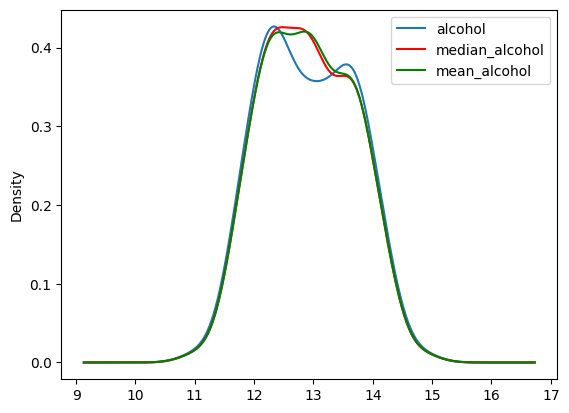

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['alcohol'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['median_alcohol'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['mean_alcohol'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

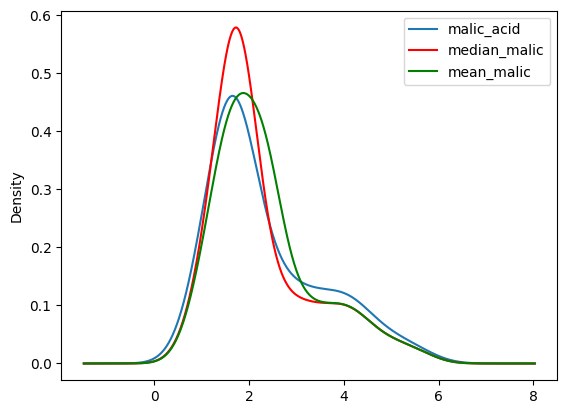

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['malic_acid'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['median_malic'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['mean_malic'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

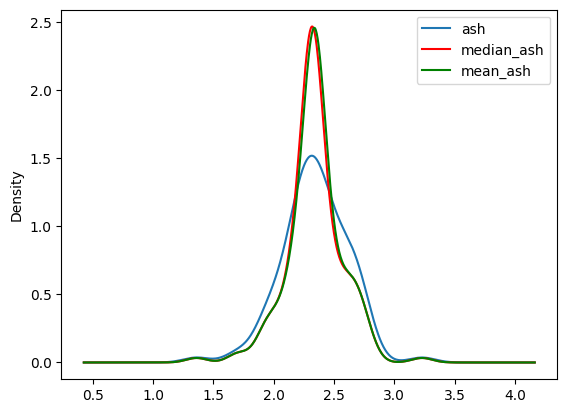

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['ash'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['median_ash'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['mean_ash'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [ ]:
X_train.cov()

,alcohol,malic_acid,ash,mean_alcohol,median_alcohol,mean_malic,median_malic,mean_ash,median_ash
alcohol,0.607663,0.138836,0.035598,0.607663,0.607663,0.119903,0.118531,0.026968,0.027102
malic_acid,0.138836,1.357970,0.066955,0.138836,0.138836,1.357970,1.357970,0.058733,0.058416
ash,0.035598,0.066955,0.074679,0.035598,0.035598,0.066955,0.066955,0.074679,0.074679
mean_alcohol,0.607663,0.138836,0.035598,0.572940,0.572940,0.113052,0.111758,0.025427,0.025553
median_alcohol,0.607663,0.138836,0.035598,0.572940,0.573067,0.113052,0.112951,0.025427,0.025595
mean_malic,0.119903,1.357970,0.066955,0.113052,0.113052,1.105776,1.105776,0.047825,0.047567
median_malic,0.118531,1.357970,0.066955,0.111758,0.112951,1.105776,1.147670,0.047825,0.049056
mean_ash,0.026968,0.058733,0.074679,0.025427,0.025427,0.047825,0.047825,0.053342,0.053342
median_ash,0.027102,0.058416,0.074679,0.025553,0.025595,0.047567,0.049056,0.053342,0.053435


In [ ]:
X_train.corr()

,alcohol,malic_acid,ash,mean_alcohol,median_alcohol,mean_malic,median_malic,mean_ash,median_ash
alcohol,1.000000,0.156222,0.171033,1.000000,1.000000,0.142033,0.138496,0.145448,0.146060
malic_acid,0.156222,1.000000,0.216615,0.156222,0.156222,1.000000,1.000000,0.196918,0.195783
ash,0.171033,0.216615,1.000000,0.171033,0.171033,0.216615,0.216615,1.000000,1.000000
mean_alcohol,1.000000,0.156222,0.171033,1.000000,0.999889,0.142033,0.137821,0.145448,0.146040
median_alcohol,1.000000,0.156222,0.171033,0.999889,1.000000,0.142017,0.139276,0.145432,0.146266
mean_malic,0.142033,1.000000,0.216615,0.142033,0.142017,1.000000,0.981579,0.196918,0.195686
median_malic,0.138496,1.000000,0.216615,0.137821,0.139276,0.981579,1.000000,0.193291,0.198095
mean_ash,0.145448,0.196918,1.000000,0.145448,0.145432,0.196918,0.193291,1.000000,0.999132
median_ash,0.146060,0.195783,1.000000,0.146040,0.146266,0.195686,0.198095,0.999132,1.000000


<Axes: >

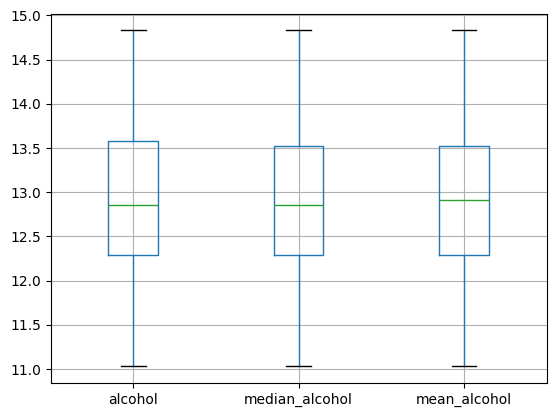

In [ ]:
X_train[['alcohol', 'median_alcohol', 'mean_alcohol']].boxplot()

<Axes: >

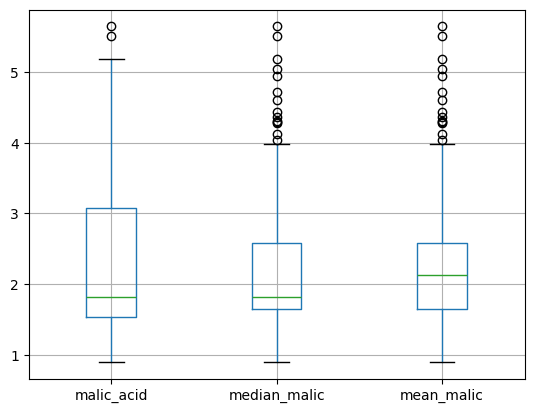

In [ ]:
X_train[['malic_acid', 'median_malic', 'mean_malic']].boxplot()

<Axes: >

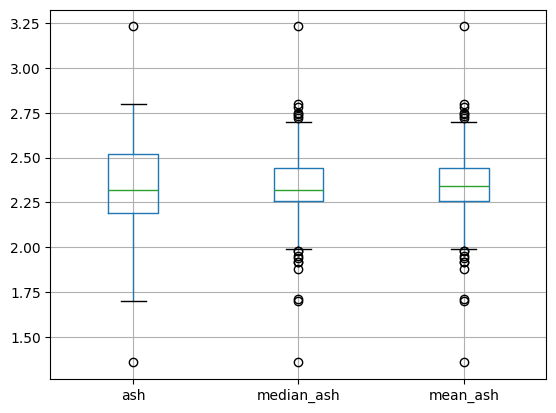

In [ ]:
X_train[['ash', 'median_ash', 'mean_ash']].boxplot()

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')
imputer3 = SimpleImputer(strategy='most_frequent')

In [ ]:
from sklearn.compose import ColumnTransformer

In [ ]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['alcohol']),
    ('imputer2',imputer2,['malic_acid']),
    ('imputer3',imputer3,['ash'])
],remainder='passthrough')

In [ ]:
trf.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['alcohol']),
                                ('imputer2', SimpleImputer(), ['malic_acid']),
                                ('imputer3',
                                 SimpleImputer(strategy='most_frequent'),
                                 ['ash'])])

In [ ]:
trf.named_transformers_['imputer1'].statistics_

array([12.86])

In [ ]:
trf.named_transformers_['imputer2'].statistics_  #mean cvalue of malic

array([2.33591304])

In [ ]:
trf.named_transformers_['imputer3'].statistics_

array([2.32])

In [ ]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [ ]:
X_train

array([[12.58      ,  1.29      ,  2.32      ],
       [11.56      ,  2.05      ,  3.23      ],
       [12.08      ,  1.83      ,  2.32      ],
       [12.29      ,  2.83      ,  2.22      ],
       [13.84      ,  4.12      ,  2.38      ],
       [12.25      ,  3.88      ,  2.2       ],
       [12.        ,  0.92      ,  2.        ],
       [13.63      ,  1.81      ,  2.7       ],
       [13.32      ,  3.24      ,  2.38      ],
       [12.86      ,  2.33591304,  2.32      ],
       [12.86      ,  1.35      ,  2.32      ],
       [14.21      ,  4.04      ,  2.44      ],
       [13.5       ,  3.12      ,  2.62      ],
       [12.37      ,  2.33591304,  2.32      ],
       [11.87      ,  4.31      ,  2.39      ],
       [12.37      ,  2.33591304,  2.32      ],
       [12.86      ,  2.33591304,  2.32      ],
       [12.16      ,  1.61      ,  2.32      ],
       [12.08      ,  2.08      ,  1.7       ],
       [12.81      ,  2.31      ,  2.4       ],
       [13.48      ,  1.67      ,  2.32 